In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
problems = ["feynman_13_61", "feynman_42_43_48", "feynman_13_61_62_70_77_100", "composite_function"]
problem_mapper = lambda p: p.replace("13_61_62_70_77_100", "c").replace("42_43_48", "b").replace("13_61", "a").replace(
    "_dense", "")
seeds = range(0, 10)
algorithms = ["ga", "gomea"]
solvers = ["cgp", "lgp"]

missing = 0
dfs = []
for pop in ["small", "large"]:  #, "diverse"]:
    div = "_large_pop" if pop == "large" else ("_diversity" if pop == "diverse" else "")
    for solver in solvers:
        for algorithm in algorithms:
            for problem in problems:
                for seed in seeds:
                    if algorithm == "gomea":
                        for fos in ["U", "RT", "LT", "LT1"]:  #, "N1", "N2"]:
                            try:
                                tmp_df = pd.read_csv(
                                    f"../results/regression/{algorithm}_{solver}_{problem}_{fos}_{seed}_fi{div}.csv", )
                            except FileNotFoundError as e:
                                print(f"{algorithm}_{solver}_{problem}_{fos}_{seed}_fi{div}")
                                missing = missing + 1
                                continue
                            tmp_df["seed"] = seed
                            tmp_df["algorithm"] = f"{algorithm}_{fos}"
                            tmp_df["problem"] = problem_mapper(problem)
                            tmp_df["solver"] = solver
                            tmp_df["pop"] = pop
                            dfs.append(tmp_df)
                    else:
                        if pop == "diverse":
                            continue
                        try:
                            tmp_df = pd.read_csv(
                                f"../results/regression/{algorithm}_{solver}_{problem}_{seed}{div}.csv", )
                        except FileNotFoundError as e:
                            print(f"{algorithm}_{solver}_{problem}_{seed}{div}")
                            missing = missing + 1
                            continue
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = algorithm
                        tmp_df["problem"] = problem_mapper(problem)
                        tmp_df["solver"] = solver
                        tmp_df["pop"] = pop
                        dfs.append(tmp_df)
regression_df = pd.concat(dfs, ignore_index=True)
regression_df.head()

,evaluation,fitness,test_accuracy,uniqueness,time,seed,algorithm,problem,solver,pop
0,100,-0.235115,-0.197651,1.0,3.49,0,ga,feynman_a,cgp,small
1,190,-0.235115,-0.197651,1.0,2.70,0,ga,feynman_a,cgp,small
2,280,-0.235115,-0.197651,1.0,1.12,0,ga,feynman_a,cgp,small
3,370,-0.235115,-0.197651,1.0,0.85,0,ga,feynman_a,cgp,small
4,460,-0.235115,-0.197651,1.0,0.90,0,ga,feynman_a,cgp,small


In [3]:
rounding_factor = 1000
regression_df["rounded_evaluation"] = (regression_df["evaluation"] / rounding_factor).round() * rounding_factor

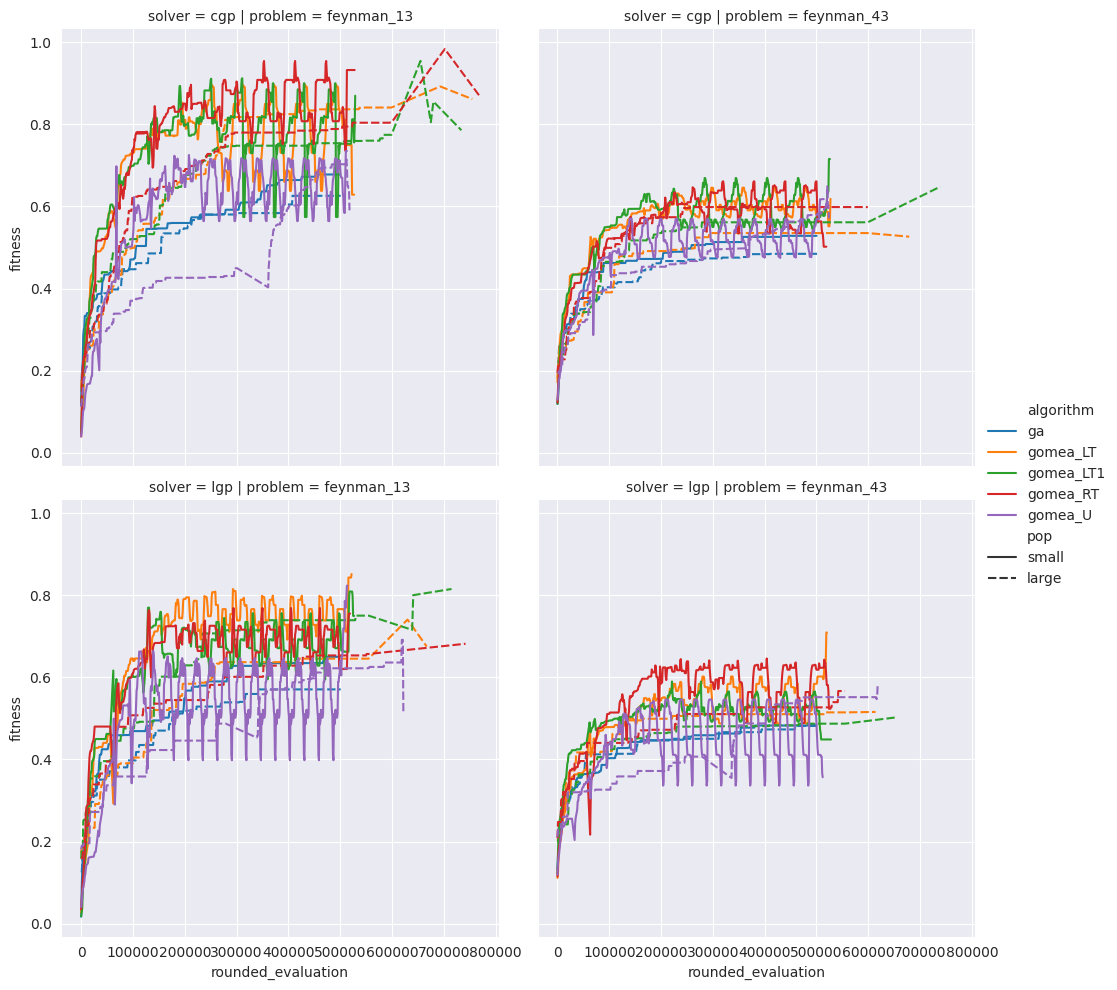

In [6]:
agg_df = (
    regression_df
    .groupby(["rounded_evaluation", "problem", "algorithm", "solver", "pop"])
    .mean()
    .reset_index()
)
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="fitness",
    col="problem",
    row="solver",
    hue="algorithm",
    style="pop",
    kind="line",
)
plt.show()

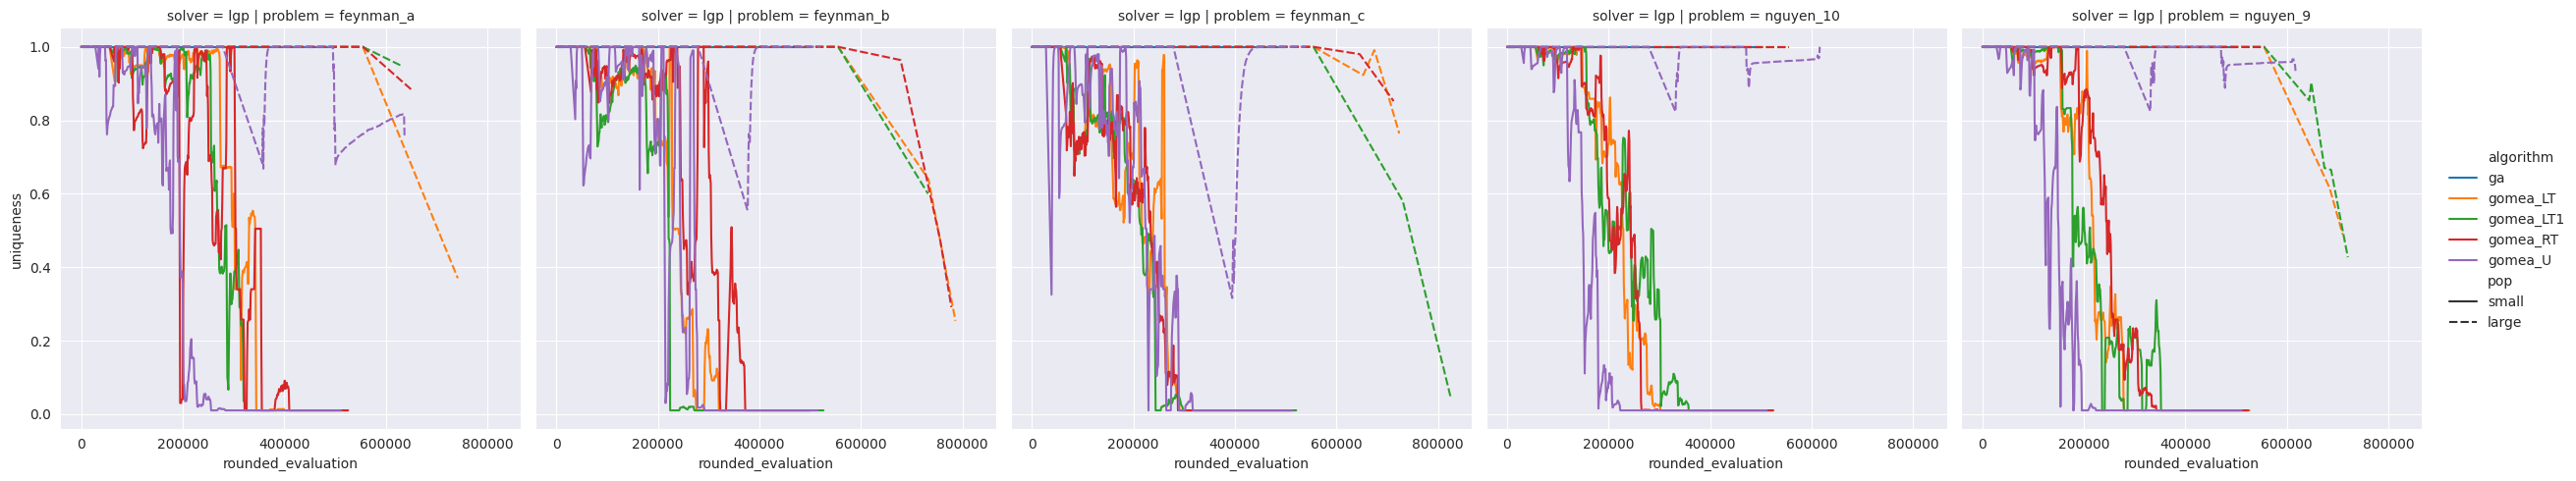

In [7]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="uniqueness",
    col="problem",
    row="solver",
    style="pop",
    hue="algorithm",
    kind="line",
)
plt.show()

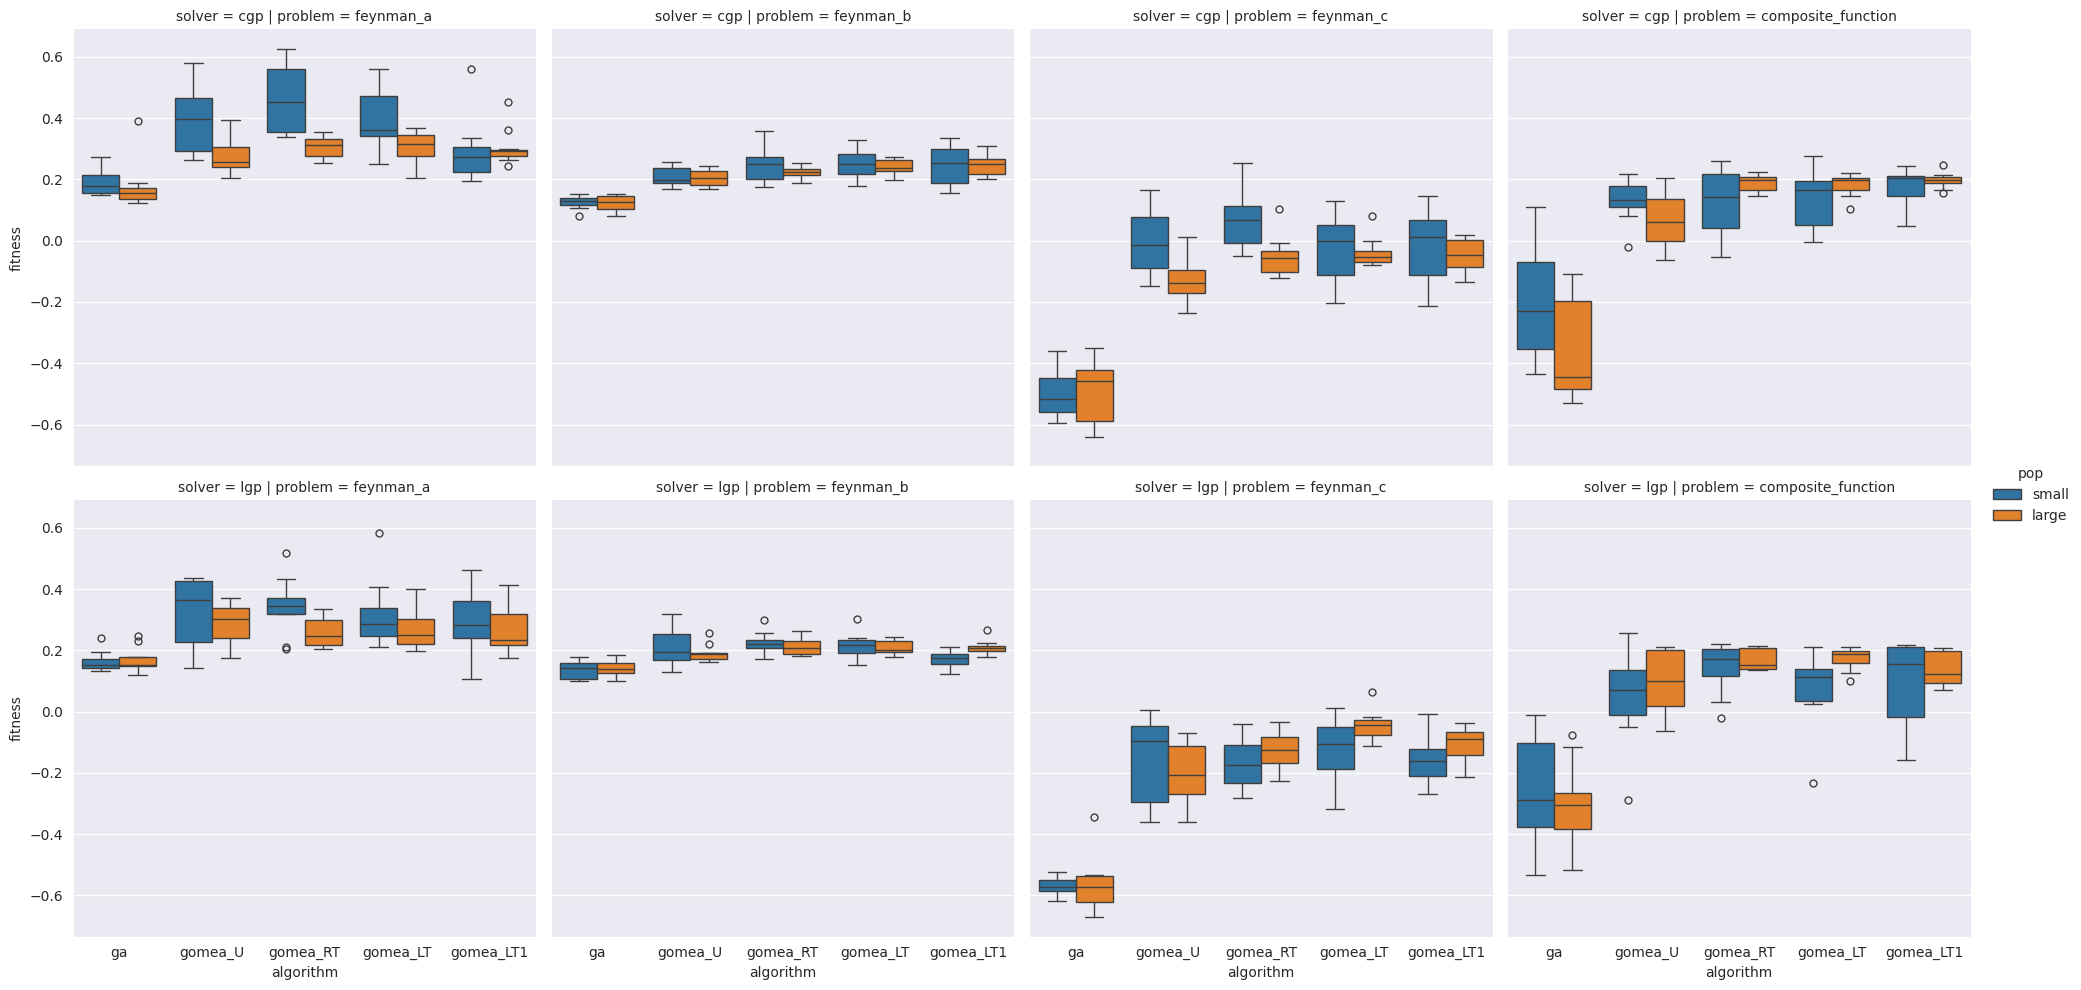

In [3]:
regression_df["max_eval"] = regression_df.groupby(["algorithm", "solver", "problem", "seed", "pop"])[
    "evaluation"].transform("max")
final_regression_df = regression_df[regression_df["evaluation"] == regression_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_regression_df, x='algorithm', y='fitness', hue="pop",
    kind='box', row='solver', col='problem',
)
# plt.ylim(0, 1.1)
plt.show()

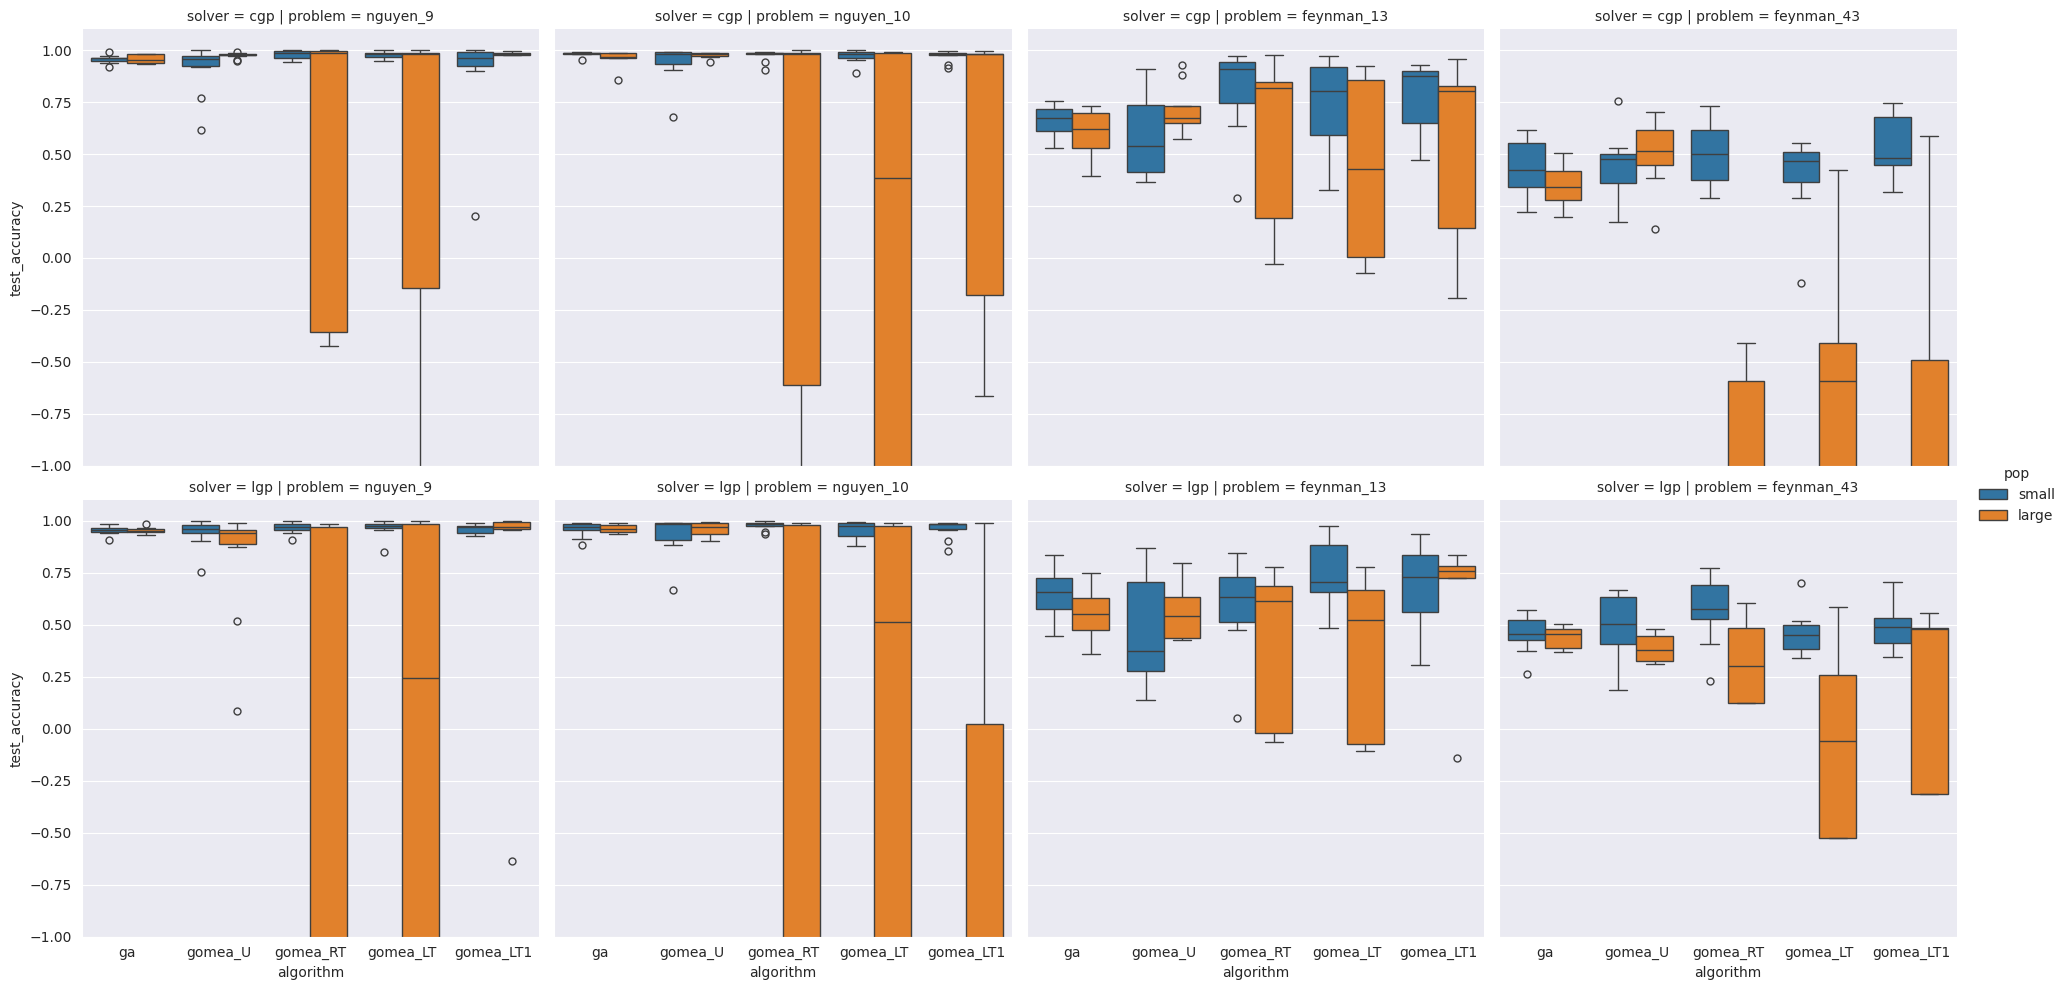

In [5]:
sns.catplot(
    data=final_regression_df, x='algorithm', y='test_accuracy', hue="pop",
    col='problem', kind='box', row="solver",  #sharey=False
)
plt.ylim(-1, 1.1)
plt.show()

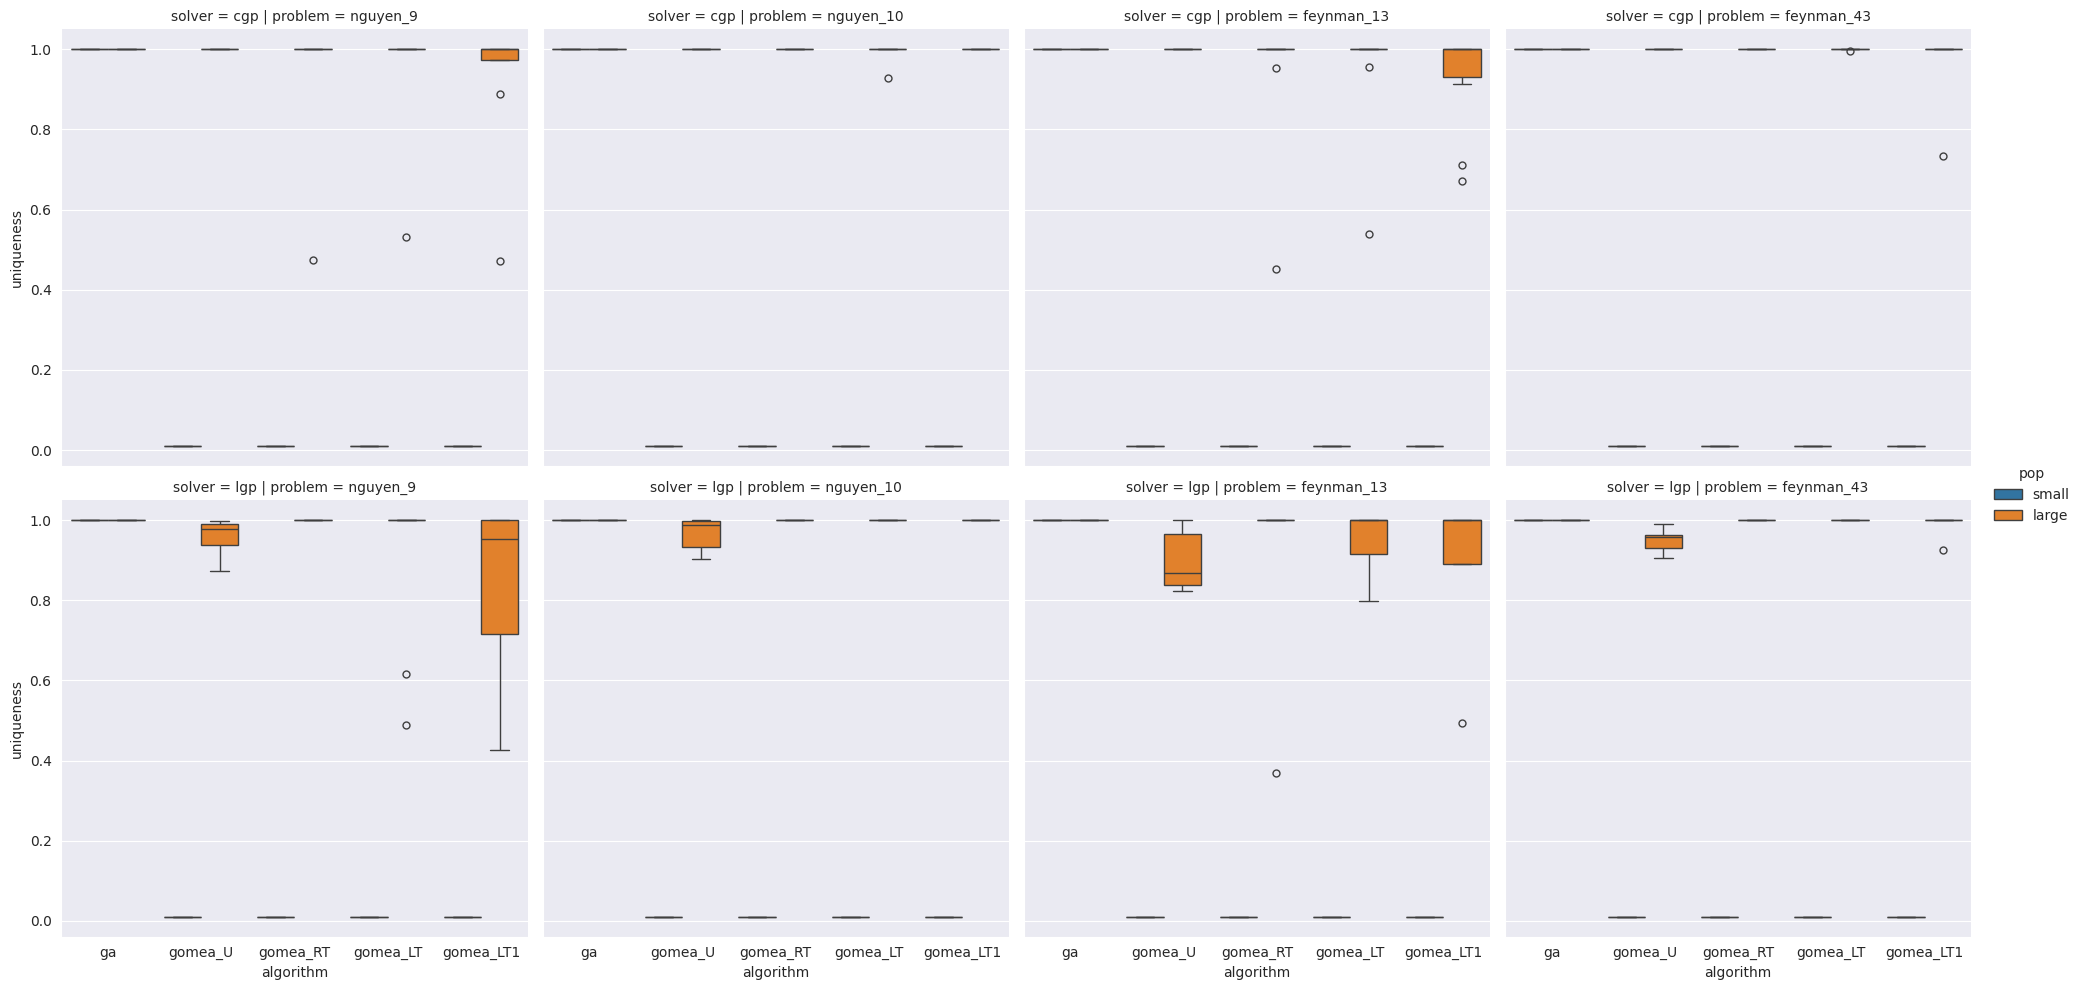

In [6]:
sns.catplot(
    data=final_regression_df, x='algorithm', y='uniqueness', hue="pop",
    col='problem', kind='box', row='solver',
)
plt.show()

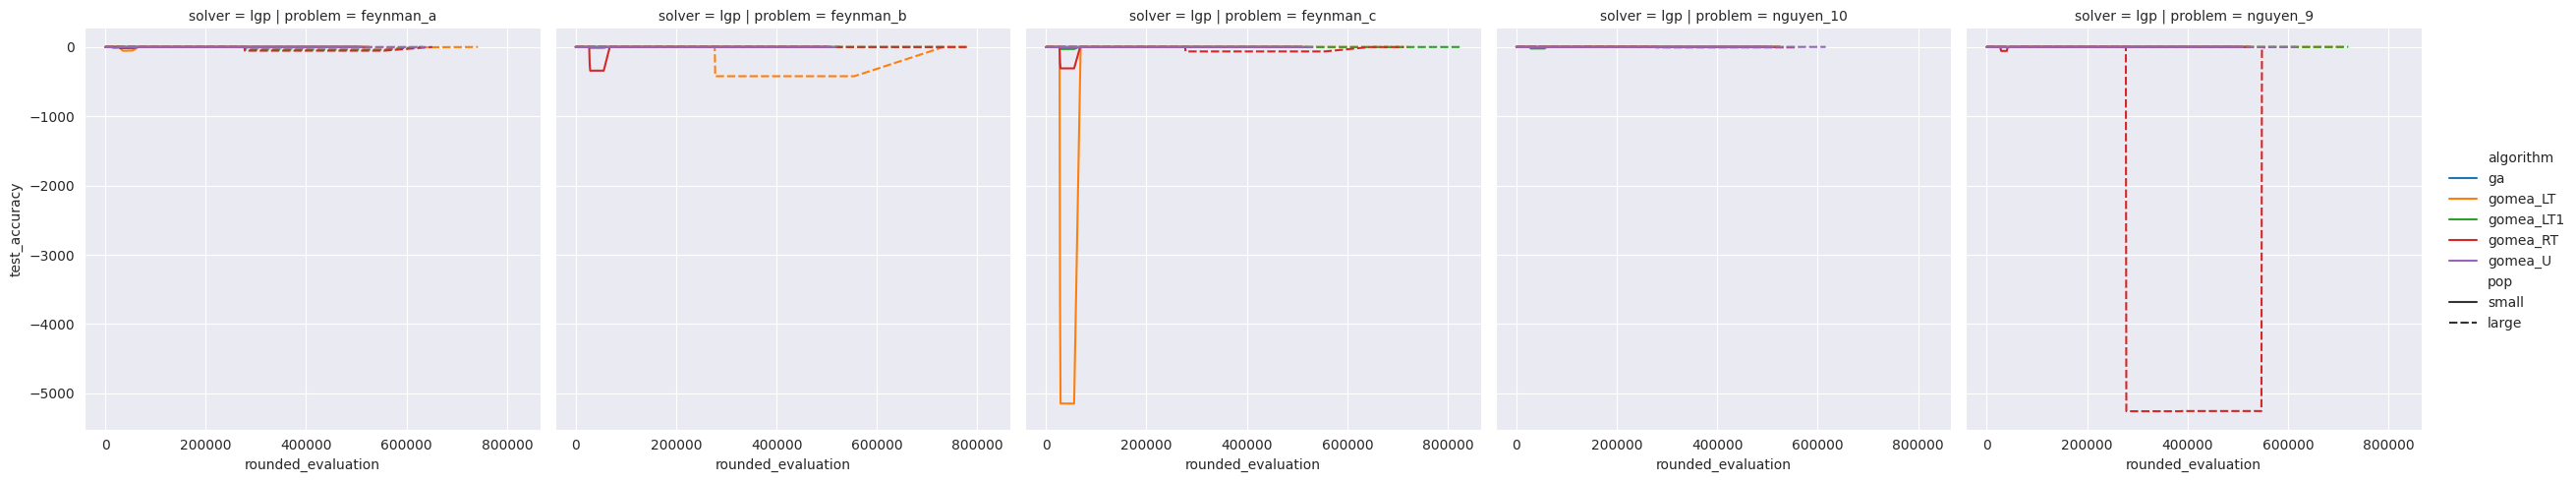

In [10]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="test_accuracy",
    col="problem",
    row="solver",
    hue="algorithm",
    style="pop",
    kind="line",
)
plt.show()

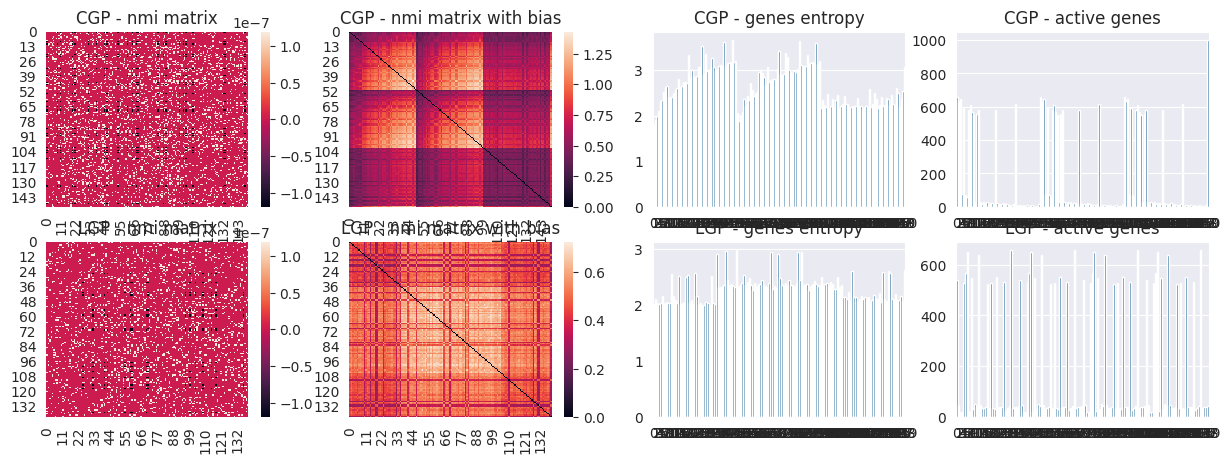

In [11]:
import jax.numpy as jnp

seed = 5
environment = "feynman_13"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]
zero_diagonal = True

fig, axs = plt.subplots(2, 4)
fig.set_figwidth(15)
fig.set_figheight(5)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/regression/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 3])
    axs[solver_idx, 3].set_title(f'{solver.upper()} - active genes')
plt.show()

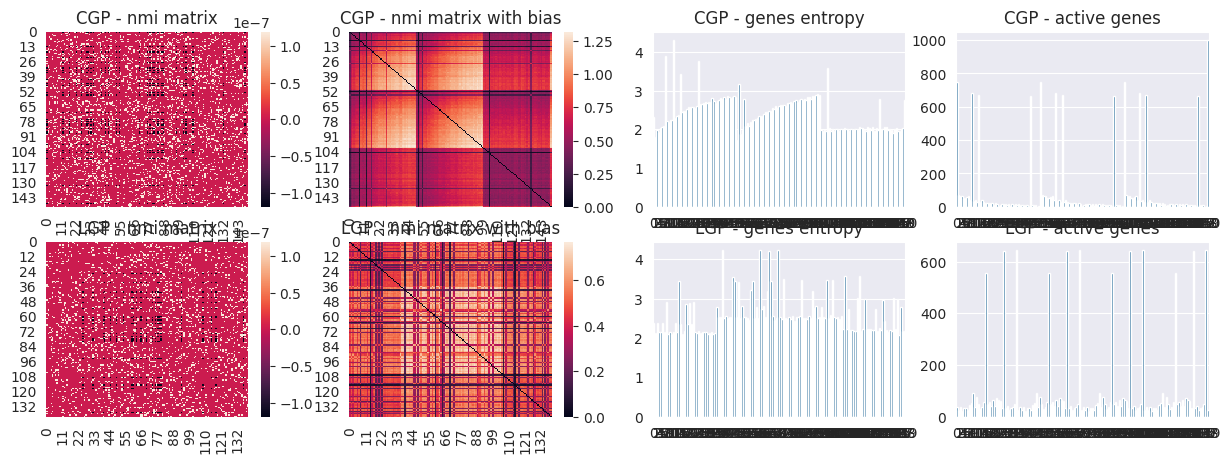

In [12]:
seed = 5
environment = "feynman_43"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]
zero_diagonal = True

fig, axs = plt.subplots(2, 4)
fig.set_figwidth(15)
fig.set_figheight(5)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/regression/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 3])
    axs[solver_idx, 3].set_title(f'{solver.upper()} - active genes')
plt.show()

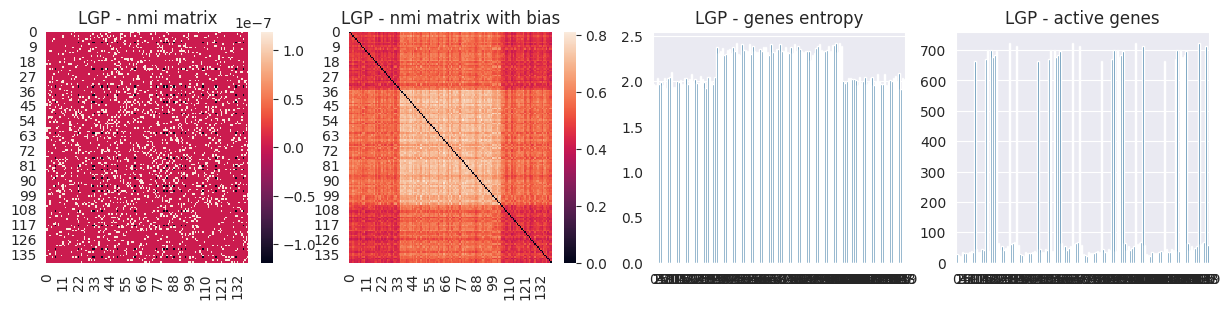

In [15]:
seed = 5
environment = "feynman_13_61"
pop_type = "_large_pop"
solvers = ["lgp"]
zero_diagonal = True

fig, axs = plt.subplots(1, 4)
fig.set_figwidth(15)
fig.set_figheight(3)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/regression/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    nmi_matrix_biased = jnp.load(f"{base_path}/nmi_matrix_biased.npy")
    if zero_diagonal:
        for i in range(len(nmi_matrix)):
            nmi_matrix = nmi_matrix.at[i, i].set(0.)
            nmi_matrix_biased = nmi_matrix_biased.at[i, i].set(0.)
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[0])
    axs[0].set_title(f'{solver.upper()} - nmi matrix')
    sns.heatmap(nmi_matrix_biased, ax=axs[1])
    axs[1].set_title(f'{solver.upper()} - nmi matrix with bias')
    sns.barplot(unique_genes, ax=axs[2])
    axs[2].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[3])
    axs[3].set_title(f'{solver.upper()} - active genes')
plt.show()

In [11]:
final_regression_df["mean_fitness"] = final_regression_df.groupby(["algorithm", "solver", "problem", "pop"])[
    "fitness"].transform("mean")

In [12]:
from scipy.stats import mannwhitneyu

p_val_threshold = 0.05
differences_dicts = []
for problem in final_regression_df.problem.unique():
    for solver in final_regression_df.solver.unique():
        for population in final_regression_df["pop"].unique():
            for algorithm in final_regression_df.algorithm.unique():
                if algorithm == "ga":
                    continue
                ga_df = final_regression_df[
                    (final_regression_df["problem"] == problem) & (final_regression_df["solver"] == solver) & (
                            final_regression_df["pop"] == population) & (final_regression_df["algorithm"] == "ga")]
                alg_df = final_regression_df[
                    (final_regression_df["problem"] == problem) & (final_regression_df["solver"] == solver) & (
                            final_regression_df["pop"] == population) & (
                            final_regression_df["algorithm"] == algorithm)]
                mean_ga = ga_df["mean_fitness"].to_list()[0]
                assert len(set(ga_df["mean_fitness"].to_list())) == 1
                mean_alg = alg_df["mean_fitness"].to_list()[0]
                assert len(set(alg_df["mean_fitness"].to_list())) == 1
                p_val = res = mannwhitneyu(ga_df["fitness"].tolist(), alg_df["fitness"].tolist()).pvalue
                result = "=" if p_val >= p_val_threshold else ("ga>gomea" if mean_ga > mean_alg else "gomea>ga")
                differences_dicts.append({
                    "problem": problem,
                    "solver": solver,
                    "population": population,
                    "algorithm": algorithm,
                    "result": result,
                    "p_value": p_val,
                })
p_values_df = pd.DataFrame(differences_dicts)
p_values_df #.head()

,problem,solver,population,algorithm,result,p_value
0,feynman_a,cgp,small,gomea_U,gomea>ga,0.000330
1,feynman_a,cgp,small,gomea_RT,gomea>ga,0.000183
2,feynman_a,cgp,small,gomea_LT,gomea>ga,0.000330
3,feynman_a,cgp,small,gomea_LT1,gomea>ga,0.004586
4,feynman_a,cgp,large,gomea_U,gomea>ga,0.002202
...,...,...,...,...,...,...
59,composite_function,lgp,small,gomea_LT1,gomea>ga,0.001315
60,composite_function,lgp,large,gomea_U,gomea>ga,0.000183
61,composite_function,lgp,large,gomea_RT,gomea>ga,0.000183
62,composite_function,lgp,large,gomea_LT,gomea>ga,0.000183
